# Raw Data EDA

## Load Libraries

In [1]:
# Data librarie
import pandas as pd
import numpy as np
from glob import glob
import os

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
# Load the email dataset
email = pd.read_csv("data/email.csv")

# Load all LDAP files
files = glob("data/LDAP/*.csv")
ldap = []

for file in files:
    # Read each LDAP file
    df = pd.read_csv(file)

    # Extract the date from the file name and store it as a column
    date = os.path.basename(file).split(".")[0]
    df["date"] = date

    ldap.append(df)

# Combine all LDAP files into a single DataFrame
ldap = pd.concat(ldap, ignore_index=True)

# Load the insider ground-truth labels
insiders = pd.read_csv("data/answers/insiders.csv")

## Data preprocessing

### email.csv

In [3]:
email.shape

(10994957, 12)

In [4]:
email.head()

,id,date,user,pc,to,cc,bcc,from,activity,size,attachments,content
0,{I1O2-B4EB49RW-7379WSQW},01/02/2010 06:36:41,HDB1666,PC-6793,Louis.Bernard.Garza@dtaa.com,Emery.Ali.Holloway@dtaa.com,Hector.Donovan.Bray@dtaa.com,Hector.Donovan.Bray@dtaa.com,Send,45659,NaN,"Now Sylvia, the object of Aminta's desire, arr..."
1,{L7E7-V4UX89RR-3036ZDHU},01/02/2010 06:40:02,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,NaN,NaN,Luke.Grant.Mcmahon@dtaa.com,View,34142,NaN,"On May 14, they picked up 44 more Iroquois at ..."
2,{S8C2-Q8YX87DJ-0516SIWZ},01/02/2010 06:42:48,HDB1666,PC-6793,Quintessa.O.Farrell@harris.com,Hector.Donovan.Bray@dtaa.com,NaN,Hector.Donovan.Bray@dtaa.com,Send,1310925,C:\28X79b6\0PAGXTJ8.doc(1119253);C:\11b38g6\5M...,Sylvia is notable for its mythological Arcadia...
3,{A1V9-O5BL46SW-1708NAEC},01/02/2010 06:45:42,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,NaN,NaN,Travis.Ezra.Warner@dtaa.com,View,23043,NaN,Lanctot (1967) and Smith do not identify any s...
4,{N6R0-M2EI82DM-5583LSUM},01/02/2010 06:47:07,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,NaN,NaN,Kenyon.William.Delacruz@dtaa.com,View,25210,NaN,Much like all the other large groups of prison...


In [5]:
email.info()

<class 'pandas.DataFrame'>
RangeIndex: 10994957 entries, 0 to 10994956
Data columns (total 12 columns):
 #   Column       Dtype
---  ------       -----
 0   id           str  
 1   date         str  
 2   user         str  
 3   pc           str  
 4   to           str  
 5   cc           str  
 6   bcc          str  
 7   from         str  
 8   activity     str  
 9   size         int64
 10  attachments  str  
 11  content      str  
dtypes: int64(1), str(11)
memory usage: 8.3 GB


In [6]:
# check missing values
email.isnull().sum()

id                    0
date                  0
user                  0
pc                    0
to                    0
cc              5618281
bcc            10443285
from                  0
activity              0
size                  0
attachments     8403243
content               0
dtype: int64

In [7]:
# check duplicated values
email.duplicated().sum()

np.int64(0)

In [8]:
# convert the date column to datetime format
email["date"] = pd.to_datetime(email["date"])

# extract date and time components for further analysis
email["year"] = email["date"].dt.year
email["month"] = email["date"].dt.month
email["day"] = email["date"].dt.day
email["hour"] = email["date"].dt.hour
email["weekday"] = email["date"].dt.day_name()

# identify the date range of the email dataset
start_date = email["date"].min()
end_date = email["date"].max()

print("Start date:", start_date)
print("End date:", end_date)

Start date: 2010-01-02 06:36:41
End date: 2011-05-31 20:10:19


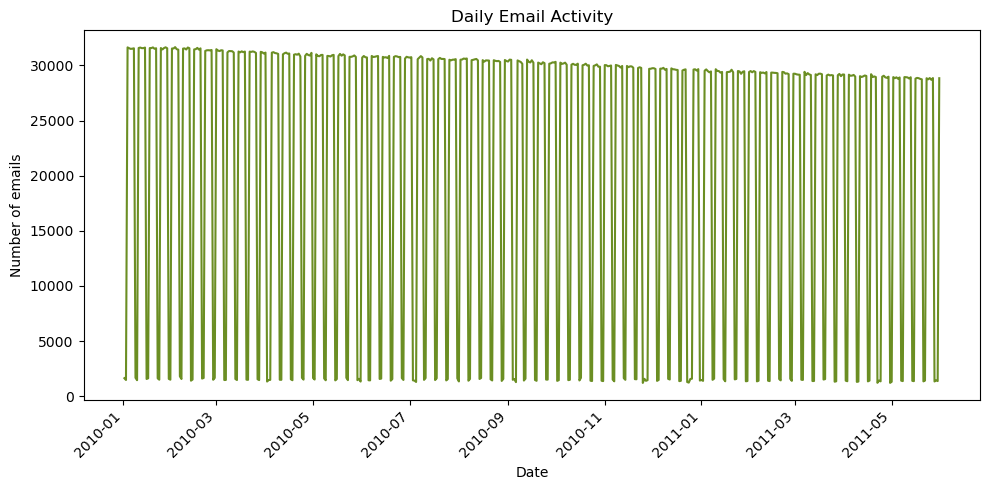

In [9]:
# plot the number of emails sent each day
plt.figure(figsize=(10, 5))

email["date"].dt.date.value_counts().sort_index().plot(color="olivedrab")

plt.xlabel("Date")
plt.ylabel("Number of emails")
plt.title("Daily Email Activity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

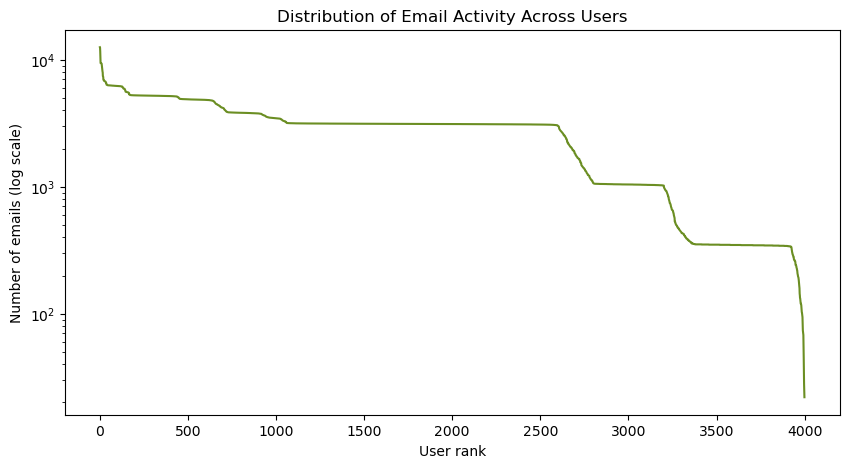

In [10]:
# plot the distribution of email activity across users
plt.figure(figsize=(10, 5))

# rank users by their total number of emails
email["user"].value_counts().sort_values(ascending=False).reset_index(drop=True).plot(
    color="olivedrab"
)

# use a logarithmic scale to better visualise the highly imbalanced distribution
plt.yscale("log")

plt.xlabel("User rank")
plt.ylabel("Number of emails (log scale)")
plt.title("Distribution of Email Activity Across Users")
plt.show()

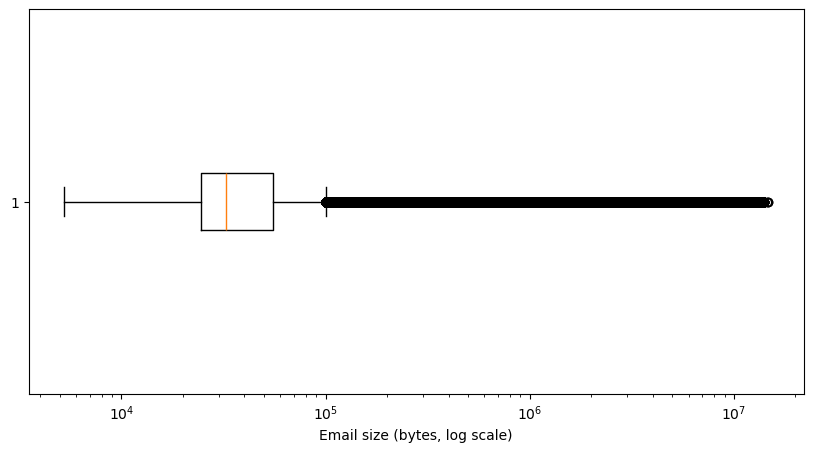

In [11]:
# plot the distribution of email sizes
plt.figure(figsize=(10, 5))

plt.boxplot(email["size"], orientation="horizontal")

# use a logarithmic scale to better visualise the wide range of email sizes
plt.xscale("log")
plt.xlabel("Email size (bytes, log scale)")
plt.show()

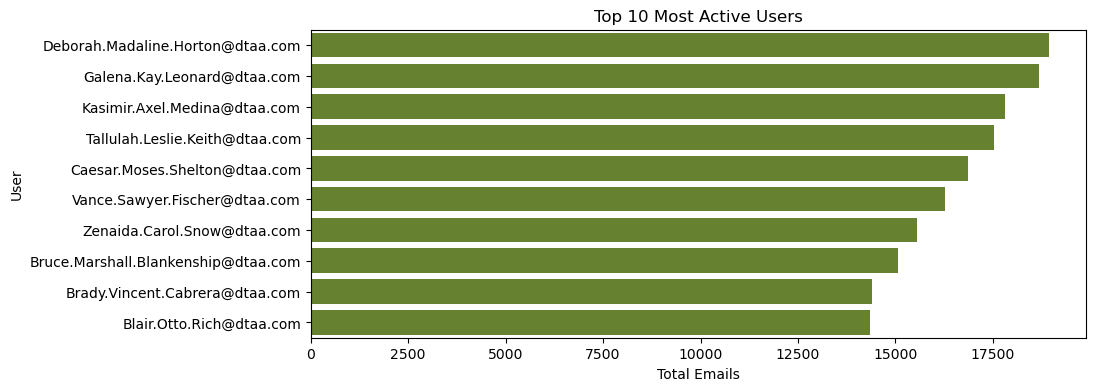

In [12]:
# count emails sent by each user
sender = email["from"].value_counts()

# split multiple recipients and count emails received by each user
receiver = (
    email["to"]
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

# combine sent and received emails to calculate total user activity
activity = (
    sender
    .add(receiver, fill_value=0)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 4))

# plot top 10 most active users based on total email activity
sns.barplot(
    x=activity.head(10).values,
    y=activity.head(10).index,
    color="olivedrab"
)

plt.xlabel("Total Emails")
plt.ylabel("User")
plt.title("Top 10 Most Active Users")
plt.show()

### LDAP

In [13]:
ldap.shape

(68923, 11)

In [14]:
ldap.head()

,employee_name,user_id,email,role,projects,business_unit,functional_unit,department,team,supervisor,date
0,Nicholas Fletcher Pruitt,NFP2441,Nicholas.Fletcher.Pruitt@dtaa.com,ITAdmin,NaN,1,1 - Adminstration,5 - Security,8 - ElectronicSecurity,Madison Charissa Malone,2009-12
1,Abraham Dante Rodgers,ADR1517,Abraham.Dante.Rodgers@dtaa.com,ProductionLineWorker,NaN,1,5 - Manufacturing_Commercial,3 - Assembly,4 - AssemblyDept,Mark William Horne,2009-12
2,Medge Wilma Blackburn,MWB4000,Medge.Wilma.Blackburn@dtaa.com,ProductionLineWorker,NaN,1,6 - Manufacturing_Government,3 - Assembly,14 - AssemblyDept,Hillary Zenaida Adkins,2009-12
3,Meghan Laurel Salazar,MLS2856,Meghan.Laurel.Salazar@dtaa.com,ProductionLineWorker,NaN,1,6 - Manufacturing_Government,3 - Assembly,8 - AssemblyDept,Demetria Sage Melendez,2009-12
4,Beau Todd Romero,BTR2026,Beau.Todd.Romero@dtaa.com,MechanicalEngineer,NaN,1,3 - ResearchAndEngineering_Government_Domestic,4 - Engineering,16 - TestAndEvalualtion,Elijah Valentine Fuentes,2009-12


In [15]:
ldap.info()

<class 'pandas.DataFrame'>
RangeIndex: 68923 entries, 0 to 68922
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   employee_name    68923 non-null  str  
 1   user_id          68923 non-null  str  
 2   email            68923 non-null  str  
 3   role             68923 non-null  str  
 4   projects         11011 non-null  str  
 5   business_unit    68923 non-null  int64
 6   functional_unit  68887 non-null  str  
 7   department       68540 non-null  str  
 8   team             66145 non-null  str  
 9   supervisor       68891 non-null  str  
 10  date             68923 non-null  str  
dtypes: int64(1), str(10)
memory usage: 16.8 MB


In [16]:
# check missing values
ldap.isnull().sum()

employee_name          0
user_id                0
email                  0
role                   0
projects           57912
business_unit          0
functional_unit       36
department           383
team                2778
supervisor            32
date                   0
dtype: int64

In [17]:
# check duplicated values
ldap.duplicated().sum()

np.int64(0)

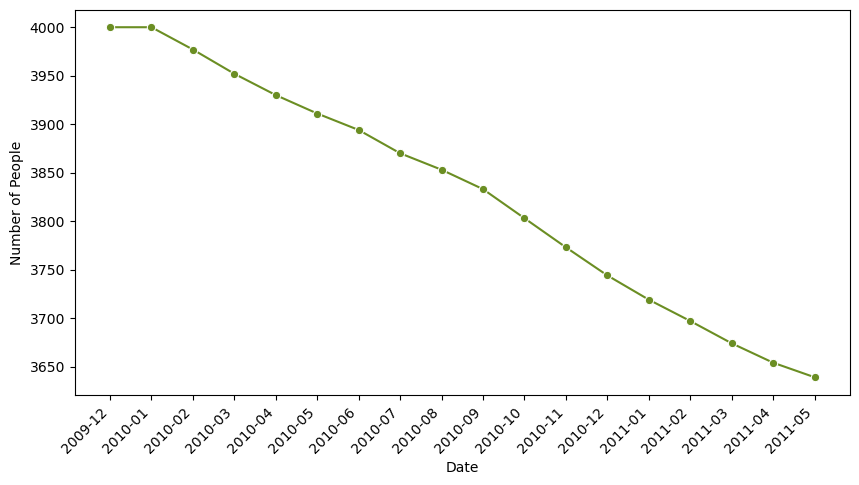

In [18]:
# count the number of unique employees recorded on each date
users_change = ldap.groupby("date")["employee_name"].nunique()

plt.figure(figsize=(10, 5))

# plot the number of unique employees over time
sns.lineplot(
    x=users_change.index,
    y=users_change.values,
    color="olivedrab",
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Number of People")
plt.xticks(rotation=45, ha="right")

plt.show()

In [19]:
# Count the number of unique organisational roles
ldap["role"].nunique()

46

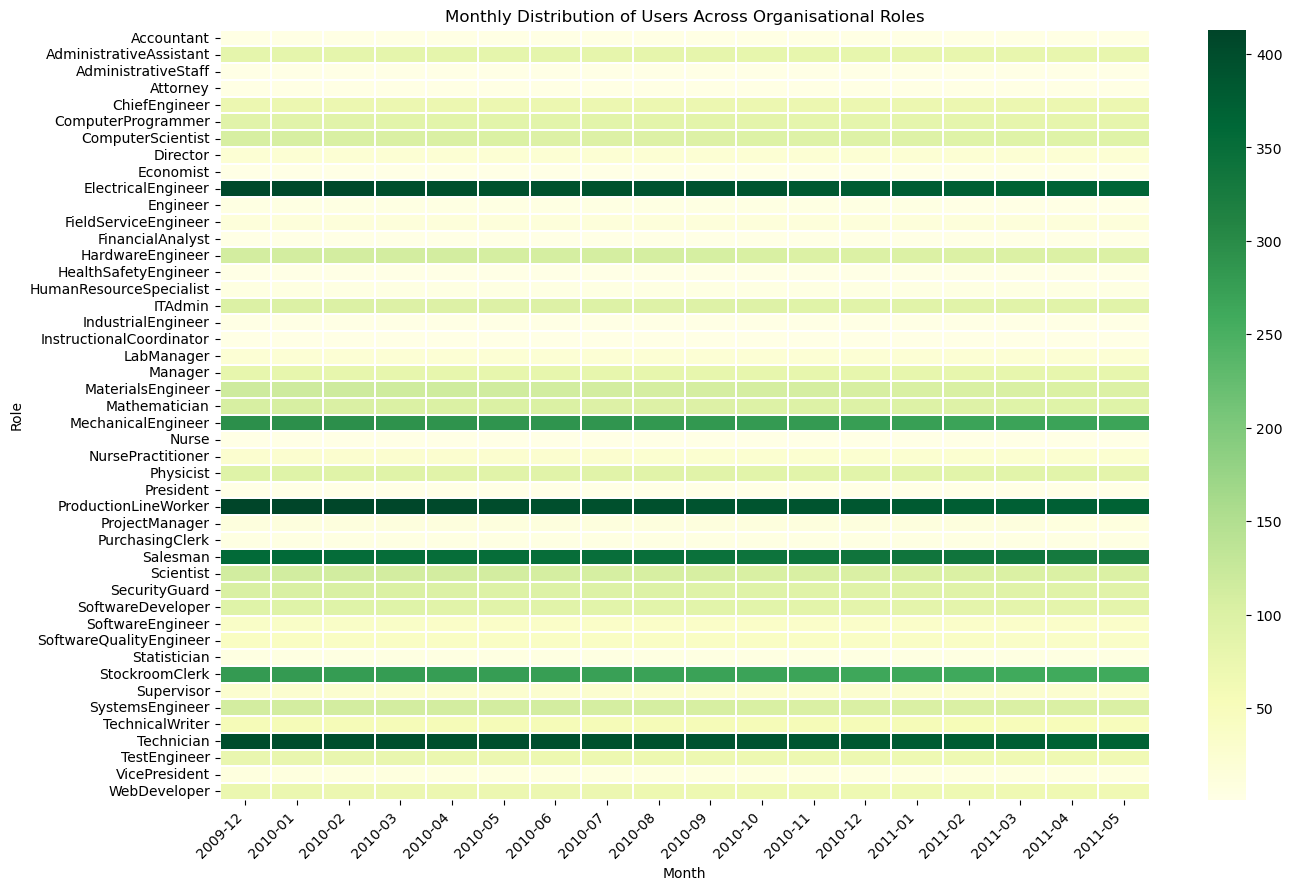

In [20]:
# count the number of unique users in each organisational role over time
role_change = (
    ldap.groupby(["date", "role"])["user_id"]
        .nunique()
        .unstack(fill_value=0)
)

plt.figure(figsize=(15, 10))

# plot the changes in role using a heatmap
sns.heatmap(
    role_change.T,
    linewidths=0.3,
    cmap="YlGn",
)

plt.xlabel("Month")
plt.ylabel("Role")
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Distribution of Users Across Organisational Roles")

plt.show()

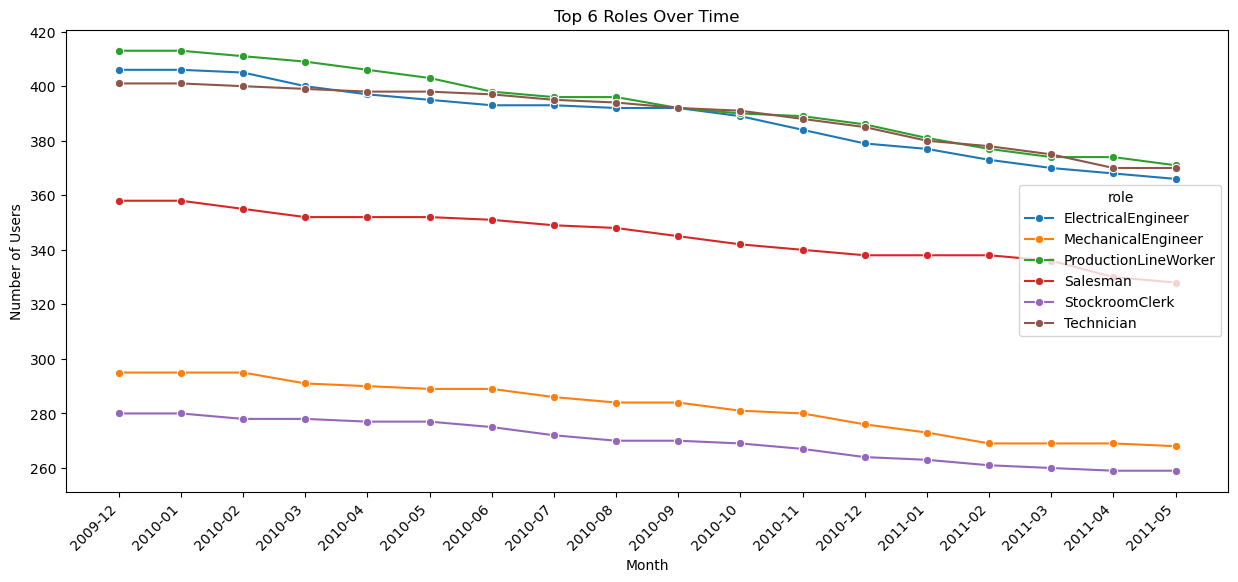

In [21]:
# identify the six most common organisational roles
top6_roles = (
    ldap["role"]
    .value_counts()
    .head(6)
    .index
)

# count the number of unique users in the top six roles over time
top6_role_change = (
    ldap[ldap["role"].isin(top6_roles)]
    .groupby(["date", "role"])["user_id"]
    .nunique()
    .reset_index(name="count")
)

plt.figure(figsize=(15, 6))

# plot changes in the number of users across the top six roles
sns.lineplot(
    data=top6_role_change,
    x="date",
    y="count",
    hue="role",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Users")
plt.title("Top 6 Roles Over Time")
plt.xticks(rotation=45, ha="right")

plt.show()

In [22]:
# number of distinct organisational roles held by each employee
role_changes = (
    ldap.groupby("employee_name")["role"]
    .nunique()
    .sort_values(ascending=False)
)

# the 10 employees with the most role changes
role_changes.head(10)

employee_name
Aaron Emery Knight       1
Aaron Fuller Frye        1
Aaron Merritt Burks      1
Aaron Myles Sparks       1
Abbot Bruce Knox         1
Abbot Drake Black        1
Abbot Russell Hopkins    1
Abbot Talon Bonner       1
Abdul Carlos Benson      1
Abdul Connor Levine      1
Name: role, dtype: int64

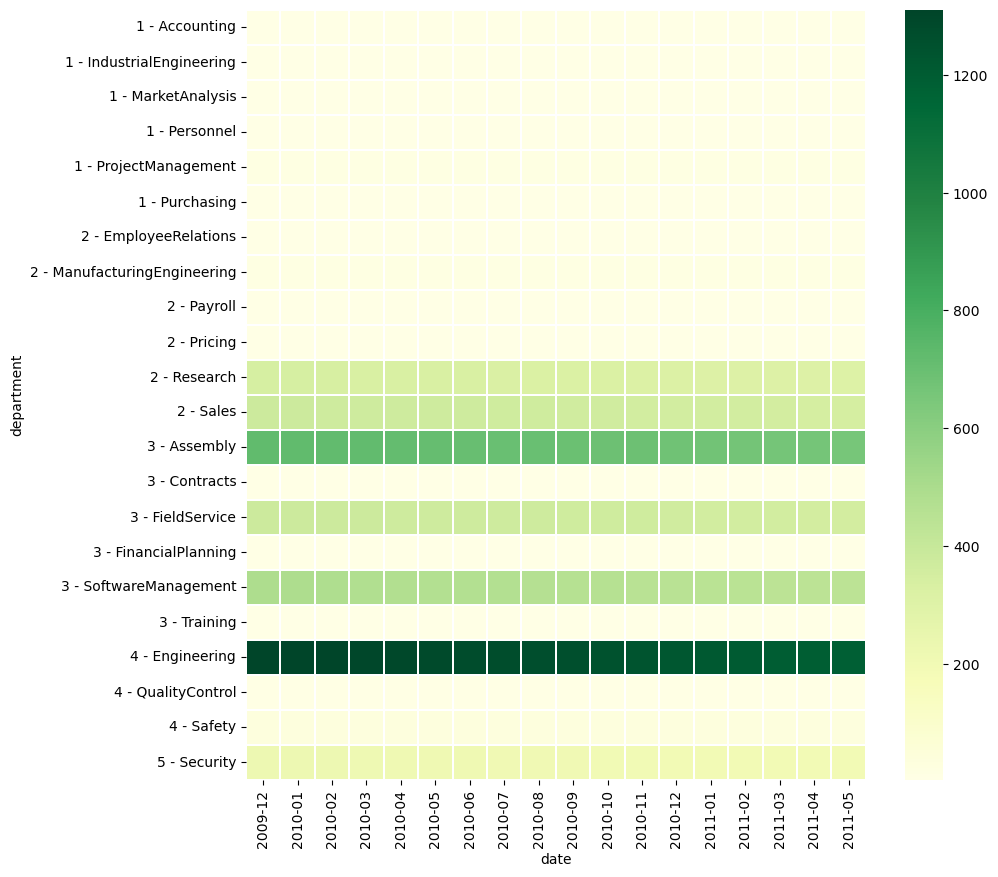

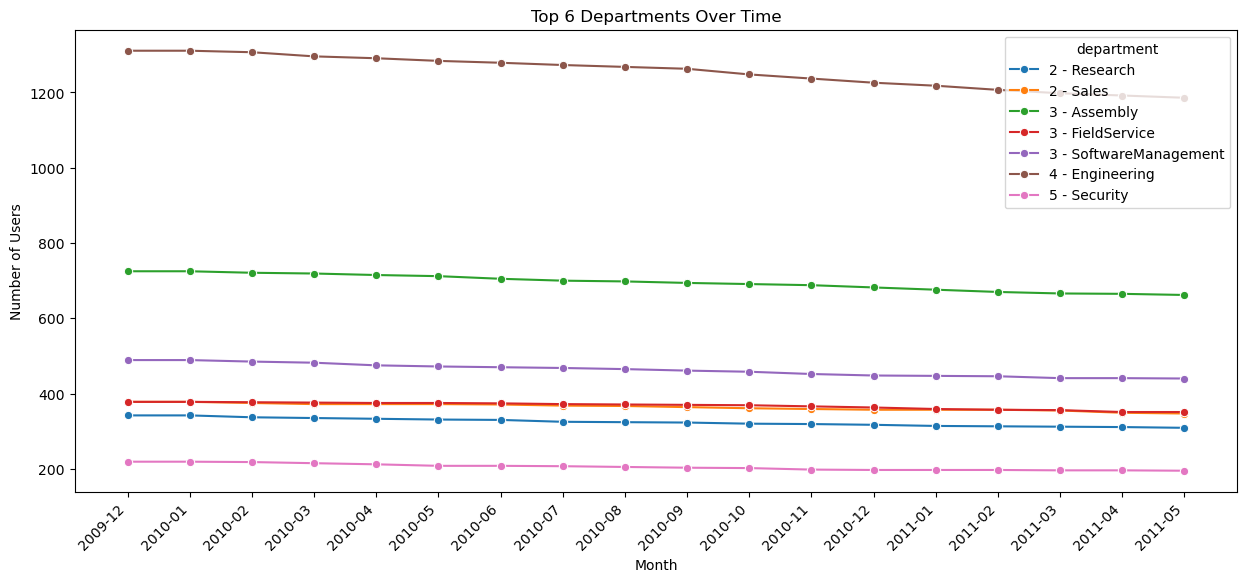

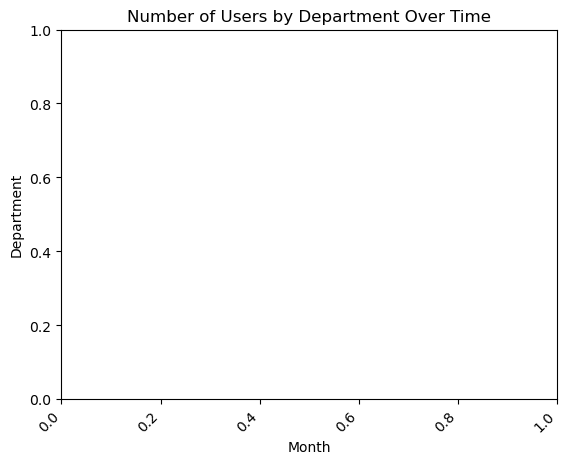

In [23]:
# the number of unique users in each department over time
department_change = (
    ldap.groupby(["date", "department"])["user_id"]
        .nunique()
        .unstack(fill_value=0)
)

plt.figure(figsize=(10, 10))

# plot the changes in department composition using a heatmap
sns.heatmap(
    department_change.T,
    linewidths=0.3,
    cmap="YlGn",
)
# identify the seven most common organisational departments
top6_department = (
    ldap["department"]
    .value_counts()
    .head(7)
    .index
)

# the number of unique users in the top departments over time
top6_department_change = (
    ldap[ldap["department"].isin(top6_department)]
    .groupby(["date", "department"])["user_id"]
    .nunique()
    .reset_index(name="count")
)

plt.figure(figsize=(15, 6))

# plot changes in the number of users across the top6 departments
sns.lineplot(
    data=top6_department_change,
    x="date",
    y="count",
    hue="department",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Users")
plt.title("Top 6 Departments Over Time")
plt.xticks(rotation=45, ha="right")

plt.show()
plt.xlabel("Month")
plt.ylabel("Department")
plt.xticks(rotation=45, ha="right")
plt.title("Number of Users by Department Over Time")

plt.show()

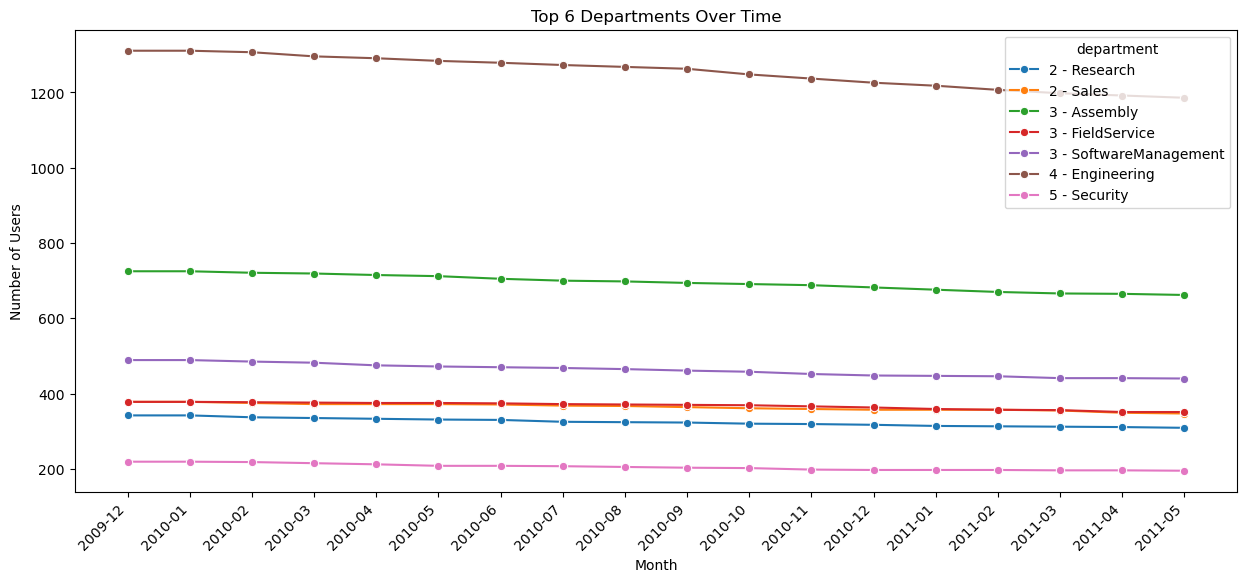

In [24]:
# identify the seven most common organisational departments
top6_department = (
    ldap["department"]
    .value_counts()
    .head(7)
    .index
)

# the number of unique users in the top departments over time
top6_department_change = (
    ldap[ldap["department"].isin(top6_department)]
    .groupby(["date", "department"])["user_id"]
    .nunique()
    .reset_index(name="count")
)

plt.figure(figsize=(15, 6))

# plot changes in the number of users across the top6 departments
sns.lineplot(
    data=top6_department_change,
    x="date",
    y="count",
    hue="department",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Users")
plt.title("Top 6 Departments Over Time")
plt.xticks(rotation=45, ha="right")

plt.show()

In [25]:
# the number of unique organisational teams
ldap["team"].nunique()

89

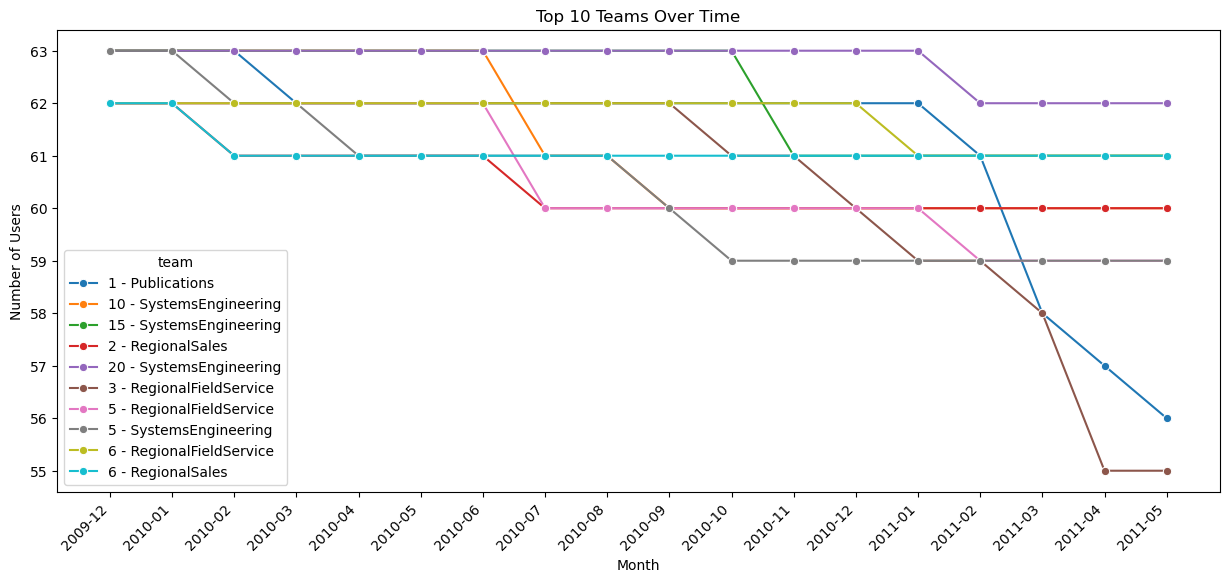

In [26]:
# the number of unique users in each team over time
team_change = (
    ldap.groupby(["date", "team"])["user_id"]
        .nunique()
        .unstack(fill_value=0)
)

# identify the 10 most common organisational teams
top10_team = (
    ldap["team"]
    .value_counts()
    .head(10)
    .index
)

# the number of unique users in the top 10 teams over time
top10_team_change = (
    ldap[ldap["team"].isin(top10_team)]
    .groupby(["date", "team"])["user_id"]
    .nunique()
    .reset_index(name="count")
)

plt.figure(figsize=(15, 6))

# plot changes in the number of users across the top 10 teams
sns.lineplot(
    data=top10_team_change,
    x="date",
    y="count",
    hue="team",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Users")
plt.title("Top 10 Teams Over Time")
plt.xticks(rotation=45, ha="right")
plt.show()

### Answer files

In [27]:
insiders.shape

(191, 6)

In [28]:
insiders.head()

,dataset,scenario,details,user,start,end
0,2.0,1,r2.csv,ONS0995,3/6/2010 1:41:56,3/20/2010 8:10:12
1,3.1,1,r3.1-1.csv,CSF0929,07/01/2010 01:24:58,07/16/2010 06:52:00
2,3.1,2,r3.1-2.csv,CCH0959,08/02/2010 10:34:31,09/30/2010 15:04:03
3,3.2,1,r3.2-1.csv,RCW0822,09/29/2010 21:10:27,10/15/2010 06:34:52
4,3.2,2,r3.2-2.csv,JCE0258,07/12/2010 08:16:02,09/03/2010 16:16:29


In [29]:
# filter the insider labels for v6.2
insiders_62 = insiders[insiders["dataset"] == 6.2].copy()

In [30]:
insiders_62

,dataset,scenario,details,user,start,end
186,6.2,1,r6.2-1.csv,ACM2278,8/18/2010 21:47:42,08/24/2010 03:48:51
187,6.2,2,r6.2-2.csv,CMP2946,02/07/2011 12:28:06,03/04/2011 12:30:25
188,6.2,3,r6.2-3.csv,PLJ1771,8/12/2010 08:09:00,08/12/2010 16:11:39
189,6.2,4,r6.2-4.csv,CDE1846,/21/2011 11:43:39,04/25/2011 17:55:00
190,6.2,5,r6.2-5.csv,MBG3183,10/12/2010 13:21:59,10/12/2010 13:22:56


In [31]:
# Correct the malformed start date by restoring the missing month ("02")
insiders_62.loc[
    insiders_62["start"].str.startswith("/"),"start"
] = "02" + insiders_62.loc[
    insiders_62["start"].str.startswith("/"),"start"
]

In [32]:
# convert insider start and end dates to datetime format
insiders_62["start"] = pd.to_datetime(insiders_62["start"])
insiders_62["end"] = pd.to_datetime(insiders_62["end"])

In [33]:
insiders_62

,dataset,scenario,details,user,start,end
186,6.2,1,r6.2-1.csv,ACM2278,2010-08-18 21:47:42,2010-08-24 03:48:51
187,6.2,2,r6.2-2.csv,CMP2946,2011-02-07 12:28:06,2011-03-04 12:30:25
188,6.2,3,r6.2-3.csv,PLJ1771,2010-08-12 08:09:00,2010-08-12 16:11:39
189,6.2,4,r6.2-4.csv,CDE1846,2011-02-21 11:43:39,2011-04-25 17:55:00
190,6.2,5,r6.2-5.csv,MBG3183,2010-10-12 13:21:59,2010-10-12 13:22:56


In [34]:
email.to_pickle("email.pkl")
ldap.to_pickle("ldap.pkl")
insiders_62.to_pickle("insider.pkl")